<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/GAN%20REAL%20DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training in progress...
Epoch 0 | Gen Loss: 0.4824 | Disc Loss: 1.4484
Epoch 300 | Gen Loss: 0.7740 | Disc Loss: 1.3168
Epoch 600 | Gen Loss: 0.6986 | Disc Loss: 1.5527
Epoch 900 | Gen Loss: 0.6586 | Disc Loss: 1.4793
Epoch 1200 | Gen Loss: 0.7155 | Disc Loss: 1.4379
Training Complete!



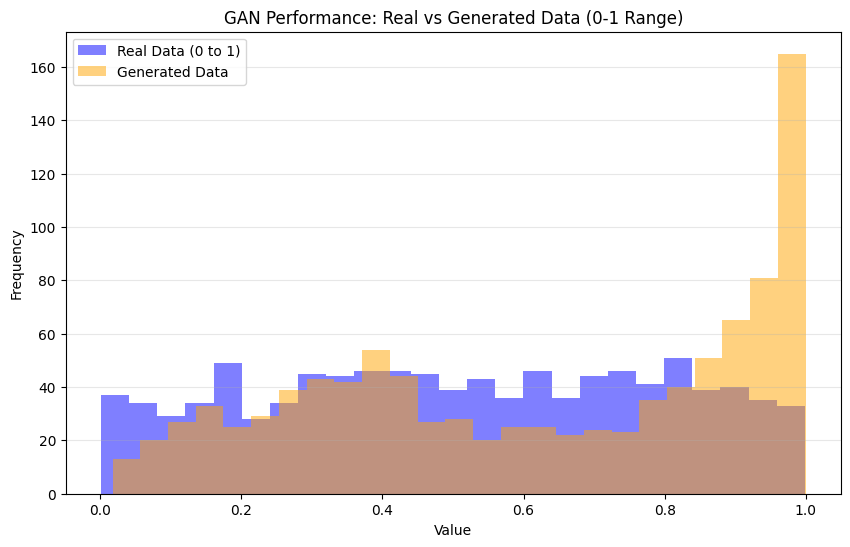

A few generated samples:
[[0.8568952 ]
 [0.2947504 ]
 [0.9868485 ]
 [0.4397024 ]
 [0.39579484]]


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. SETUP THE REAL DATA (Numbers between 0 and 1)
# ---------------------------------------------------------
def get_real_data(n=1000):
    # Creating data points randomly distributed between 0 and 1
    return torch.rand(n, 1)

# ---------------------------------------------------------
# 2. DEFINE THE GAN MODELS
# ---------------------------------------------------------

# The Generator: Learns to create data in the 0-1 range
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid() # This ensures the output is always between 0 and 1
        )
    def forward(self, x):
        return self.model(x)

# The Discriminator: The "Judge" checking if the number is Real or Fake
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

# Initialize models
generator = Generator()
discriminator = Discriminator()

# Settings for training
criterion = nn.BCELoss()
gen_optimizer = optim.Adam(generator.parameters(), lr=0.002)
disc_optimizer = optim.Adam(discriminator.parameters(), lr=0.002)

# ---------------------------------------------------------
# 3. THE TRAINING LOOP
# ---------------------------------------------------------
epochs = 1500
batch_size = 64

print("Training in progress...")

for epoch in range(epochs):
    # --- Step A: Train Discriminator ---
    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)

    # Real data pass
    real_data = get_real_data(batch_size)
    output_real = discriminator(real_data)
    loss_real = criterion(output_real, real_labels)

    # Fake data pass
    noise = torch.randn(batch_size, 1)
    fake_data = generator(noise)
    output_fake = discriminator(fake_data.detach())
    loss_fake = criterion(output_fake, fake_labels)

    # Update Discriminator
    loss_d = loss_real + loss_fake
    disc_optimizer.zero_grad()
    loss_d.backward()
    disc_optimizer.step()

    # --- Step B: Train Generator ---
    output = discriminator(fake_data)
    # Generator wants the Discriminator to believe fakes are REAL (1)
    loss_g = criterion(output, real_labels)

    gen_optimizer.zero_grad()
    loss_g.backward()
    gen_optimizer.step()

    if epoch % 300 == 0:
        print(f"Epoch {epoch} | Gen Loss: {loss_g.item():.4f} | Disc Loss: {loss_d.item():.4f}")

print("Training Complete!\n")

# ---------------------------------------------------------
# 4. RESULTS AND PLOTTING
# ---------------------------------------------------------
# Generate 1000 samples to compare with real data
with torch.no_grad():
    test_noise = torch.randn(1000, 1)
    generated_data = generator(test_noise).numpy()
    real_data_samples = get_real_data(1000).numpy()

# Visual Comparison Plot
plt.figure(figsize=(10, 6))
plt.hist(real_data_samples, bins=25, color='blue', alpha=0.5, label='Real Data (0 to 1)')
plt.hist(generated_data, bins=25, color='orange', alpha=0.5, label='Generated Data')
plt.title("GAN Performance: Real vs Generated Data (0-1 Range)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Show a few raw numbers for the "Show generated samples" requirement
print("A few generated samples:")
print(generated_data[:5])